In [1]:
import numpy as np

# Gradient descent

This version works for one input column or multiple input columns.


In [2]:
def gradient_descent(X, y, w, b, learning_rate=0.01, iterations=1000):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    w = np.asarray(w, dtype=float).copy()
    b = float(b)

    # Make a single feature look like a matrix with one column.
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    m = len(y)

    for _ in range(iterations):
        predictions = X.dot(w) + b
        errors = predictions - y

        dw = (2 / m) * X.T.dot(errors)
        db = (2 / m) * np.sum(errors)

        w -= learning_rate * dw
        b -= learning_rate * db

    return w, b


# delivery-time dataset

It follows a quadratic pattern exactly.


In [3]:
distances = np.array([2, 4, 6, 8, 10, 12], dtype=float)
actual_times = np.array([11, 21, 35, 53, 75, 101], dtype=float)


# Fit the same straight-line model


In [4]:
w_linear, b_linear = gradient_descent(
    distances,
    actual_times,
    w=np.array([0.0]),
    b=0.0,
    learning_rate=0.001,
    iterations=20000
)

linear_predictions = distances * w_linear[0] + b_linear
linear_errors = actual_times - linear_predictions

print(f"Weight: {w_linear[0]:.4f}")
print(f"Bias:   {b_linear:.4f}")
print()
print("Distance | Actual | Predicted | Error")
print("---------|--------|-----------|------")

for distance, actual, prediction, error in zip(
    distances, actual_times, linear_predictions, linear_errors
):
    print(f"{distance:8.0f} | {actual:6.1f} | {prediction:9.1f} | {error:+.1f}")


Weight: 8.9992
Bias:   -13.6593

Distance | Actual | Predicted | Error
---------|--------|-----------|------
       2 |   11.0 |       4.3 | +6.7
       4 |   21.0 |      22.3 | -1.3
       6 |   35.0 |      40.3 | -5.3
       8 |   53.0 |      58.3 | -5.3
      10 |   75.0 |      76.3 | -1.3
      12 |  101.0 |      94.3 | +6.7


# Build the `x²` feature


In [5]:
distance_squared = distances ** 2

X = np.column_stack([distances, distance_squared])

print(X)


[[  2.   4.]
 [  4.  16.]
 [  6.  36.]
 [  8.  64.]
 [ 10. 100.]
 [ 12. 144.]]


# Scale both inputs


In [6]:
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

X_scaled = (X - X_mean) / X_std

print("Mean:", X_mean)
print("Std :", X_std)
print()
print("Scaled X:")
print(X_scaled)


Mean: [ 7.         60.66666667]
Std : [ 3.41565026 48.8489736 ]

Scaled X:
[[-1.46385011 -1.16003802]
 [-0.87831007 -0.91438291]
 [-0.29277002 -0.50495773]
 [ 0.29277002  0.06823753]
 [ 0.87831007  0.80520286]
 [ 1.46385011  1.70593827]]


# Train polynomial regression


In [7]:
w_poly, b_poly = gradient_descent(
    X_scaled,
    actual_times,
    w=np.zeros(2),
    b=0.0,
    learning_rate=0.1,
    iterations=5000
)

predictions = X_scaled.dot(w_poly) + b_poly

print("Weights for scaled inputs:", w_poly)
print("Bias:", b_poly)
print()
print("Predictions:", predictions)


Weights for scaled inputs: [ 6.83130052 24.4244868 ]
Bias: 49.33333333333332

Predictions: [ 11.  21.  35.  53.  75. 101.]


# Convert the learned weights back to the original scale


In [8]:
original_weights = w_poly / X_std
original_bias = b_poly - np.sum(w_poly * X_mean / X_std)

w1, w2 = original_weights

print(f"Weight for x  : {w1:.4f}")
print(f"Weight for x² : {w2:.4f}")
print(f"Bias          : {original_bias:.4f}")
print()
print(f"prediction = {w1:.4f} × x + {w2:.4f} × x² + {original_bias:.4f}")


Weight for x  : 2.0000
Weight for x² : 0.5000
Bias          : 5.0000

prediction = 2.0000 × x + 0.5000 × x² + 5.0000


In [9]:
print("Distance | Actual | Predicted | Error")
print("---------|--------|-----------|------")

for distance, actual, prediction in zip(
    distances, actual_times, predictions
):
    error = actual - prediction
    print(f"{distance:8.0f} | {actual:6.1f} | {prediction:9.1f} | {error:+.1f}")


Distance | Actual | Predicted | Error
---------|--------|-----------|------
       2 |   11.0 |      11.0 | +0.0
       4 |   21.0 |      21.0 | -0.0
       6 |   35.0 |      35.0 | -0.0
       8 |   53.0 |      53.0 | -0.0
      10 |   75.0 |      75.0 | -0.0
      12 |  101.0 |     101.0 | +0.0


# Plot the straight line and polynomial curve


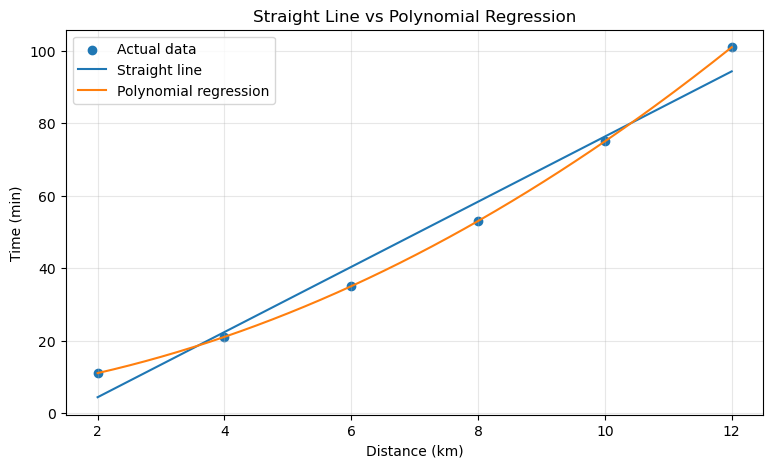

In [10]:
import matplotlib.pyplot as plt

x_plot = np.linspace(distances.min(), distances.max(), 200)

linear_plot = w_linear[0] * x_plot + b_linear
poly_plot = w1 * x_plot + w2 * (x_plot ** 2) + original_bias

plt.figure(figsize=(9, 5))
plt.scatter(distances, actual_times, label="Actual data")
plt.plot(x_plot, linear_plot, label="Straight line")
plt.plot(x_plot, poly_plot, label="Polynomial regression")
plt.xlabel("Distance (km)")
plt.ylabel("Time (min)")
plt.title("Straight Line vs Polynomial Regression")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
